# Gene-Disease Association Prediction
***Artificial Intelligence For Science - 4960*** <br>
***Task Three - Traditional AI: Support Vector Regression, Random Forests, Gradient Boosting*** <br>
***By: Swaroop Sridhar*** <br>



First we import all necessary libraries:
- numpy and pandas for data manipulation
- matplotlib and seaborn for visualization
- TDC for dataset loading
- scikit-learn modules for machine learning tasks


In [1]:
#important general initial imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tdc.multi_pred import GDA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from tdc.multi_pred import GDA

Next we:

- Loads the DisGeNET dataset
- Analyzes sequence lengths of genes and disease descriptions
- Prints basic statistics about the data
- Creates initial feature dataframe

In [2]:
#load the DisGeNET dataset.
data = GDA(name='DisGeNET')
split = data.get_split()

train_gene_lengths = [len(seq) for seq in split['train']['Gene']]
train_disease_lengths = [len(desc) for desc in split['train']['Disease']]

print("Gene Sequence Statistics:")
print(f"Max length: {max(train_gene_lengths)}")
print(f"Min length: {min(train_gene_lengths)}")
print(f"Mean length: {np.mean(train_gene_lengths):.2f}")

print("\nDisease Description Statistics:")
print(f"Max length: {max(train_disease_lengths)}")
print(f"Min length: {min(train_disease_lengths)}")
print(f"Mean length: {np.mean(train_disease_lengths):.2f}")

X = pd.DataFrame({
    'sequence': split['train']['Gene'],
    'disease': split['train']['Disease']
})
y = split['train']['Y']

print("\nExample data:")
print(split['train'].head())

Found local copy...
Loading...
Done!


Gene Sequence Statistics:
Max length: 34350
Min length: 10
Mean length: 690.71

Disease Description Statistics:
Max length: 5222
Min length: 29
Mean length: 501.85

Example data:
   Gene_ID                                               Gene Disease_ID  \
0        1  MSMLVVFLLLWGVTWGPVTEAAIFYETQPSLWAESESLLKPLANVT...   C0019209   
1        1  MSMLVVFLLLWGVTWGPVTEAAIFYETQPSLWAESESLLKPLANVT...   C0036341   
2        2  MGKNKLLHPSLVLLLLVLLPTDASVSGKPQYMVLVPSLLHTETTEK...   C0002395   
3        2  MGKNKLLHPSLVLLLLVLLPTDASVSGKPQYMVLVPSLLHTETTEK...   C0011265   
4        2  MGKNKLLHPSLVLLLLVLLPTDASVSGKPQYMVLVPSLLHTETTEK...   C0019202   

                                             Disease    Y  
0   Hepatomegaly: Abnormal enlargement of the liver.  0.3  
1  Schizophrenia: Schizophrenia is highly heritab...  0.3  
2  Alzheimer's Disease: Alzheimer disease is the ...  0.5  
3  Presenile dementia: The presence of dementia i...  0.3  
4  Hepatolenticular Degeneration: Wilson disease ...  0.3  


Then we define a function that converts amino acid sequences into numerical features by calculating:

- Sequence length
- Amino acid frequencies
- Biochemical properties (hydrophobic, polar, charged ratios)

In [3]:
def create_sequence_features(sequence):
    #convert amino acid sequence to numerical features.
    #calc sequence length.
    length = len(sequence)
    
    #calculate amino acid frequencies.
    aa_freq = {}
    for aa in 'ACDEFGHIKLMNPQRSTVWY':
        aa_freq[aa] = sequence.count(aa) / length
    
    #calculate the basic properties.
    hydrophobic = sum(sequence.count(aa) for aa in 'AILMFWYV') / length
    polar = sum(sequence.count(aa) for aa in 'QNSTC') / length
    charged = sum(sequence.count(aa) for aa in 'RHKDE') / length
    
    return [length, hydrophobic, polar, charged] + list(aa_freq.values())

This part transforms raw data into model-ready features by:

- Converts disease descriptions to numerical features using TF-IDF
- Processes gene sequences using the feature engineering function
- Combines both feature sets
- Scales features for model training

In [4]:
#this converts disease descriptions using TF-IDF.
tfidf = TfidfVectorizer(max_features=100)
disease_features = tfidf.fit_transform(X['disease'])

#process the sequence features.
sequence_features = np.array([create_sequence_features(seq) for seq in X['sequence']])

#combine the features.
X_combined = np.hstack((sequence_features, disease_features.toarray()))

X_test = pd.DataFrame({
    'sequence': split['test']['Gene'],
    'disease': split['test']['Disease']
})
y_test = split['test']['Y']

test_disease_features = tfidf.transform(X_test['disease'])
test_sequence_features = np.array([create_sequence_features(seq) for seq in X_test['sequence']])
X_test_combined = np.hstack((test_sequence_features, test_disease_features.toarray()))

#scale features.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_combined)
X_test_scaled = scaler.transform(X_test_combined)
y_train = y

This is a utility function that:

- Trains a model
- Makes predictions
- Calculates performance metrics (MSE and R²)

In [5]:
#for training model and evaluating its performance.
def train_and_evaluate(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    return mse, r2, y_pred

This trains and evaluates the three models:

- Support Vector Regression (SVR)
- Random Forest
- Gradient Boosting

and calculates multiple performance metrics such as:
- Mean Squared Error
- Mean Absolute Error
- R-squared Score
-Pearson Correlation

In [6]:
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error

# Support Vector Regression
svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr_mse, svr_r2, svr_pred = train_and_evaluate(svr_model, X_train_scaled, X_test_scaled, y_train, y_test)

# Random Forest
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, n_jobs=-1, random_state=42)
rf_mse, rf_r2, rf_pred = train_and_evaluate(rf_model, X_train_scaled, X_test_scaled, y_train, y_test)

# Gradient Boosting
gb_model = GradientBoostingRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
gb_mse, gb_r2, gb_pred = train_and_evaluate(gb_model, X_train_scaled, X_test_scaled, y_train, y_test)

for name, pred in [('SVR', svr_pred), ('Random Forest', rf_pred), ('Gradient Boosting', gb_pred)]:
    pearson_corr, _ = pearsonr(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    print(f"\n{name} Results:")
    print(f"Mean Squared Error: {mean_squared_error(y_test, pred):.4f}")
    print(f"Mean Absolute Error: {mae:.4f}")
    print(f"R-squared Score: {r2_score(y_test, pred):.4f}")
    print(f"Pearson Correlation: {pearson_corr:.4f}")


SVR Results:
Mean Squared Error: 0.0136
Mean Absolute Error: 0.0903
R-squared Score: 0.2237
Pearson Correlation: 0.5553

Random Forest Results:
Mean Squared Error: 0.0118
Mean Absolute Error: 0.0692
R-squared Score: 0.3311
Pearson Correlation: 0.5784

Gradient Boosting Results:
Mean Squared Error: 0.0113
Mean Absolute Error: 0.0656
R-squared Score: 0.3583
Pearson Correlation: 0.5992


Here we visualize and analyze the feature importance by:

- Creates interpretable feature names
- Plots top 20 important features for both RF and GB models
- Provides a summary of the most important features

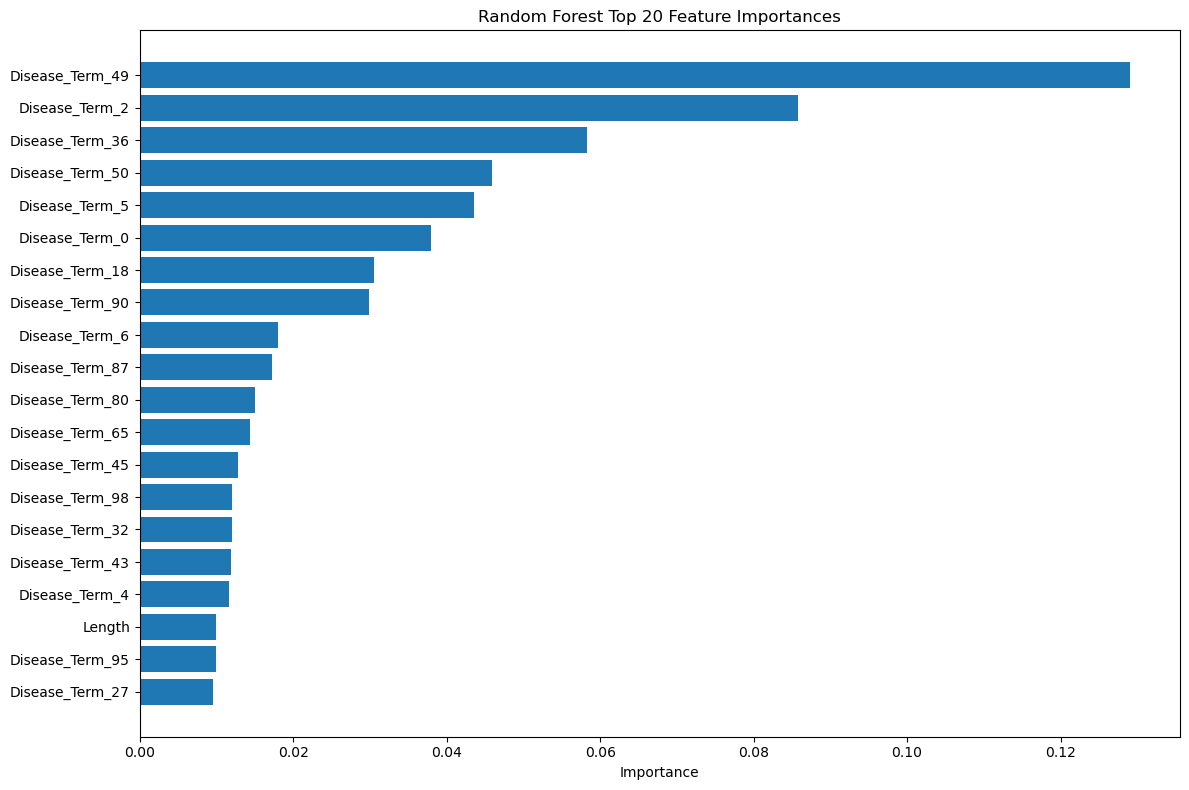

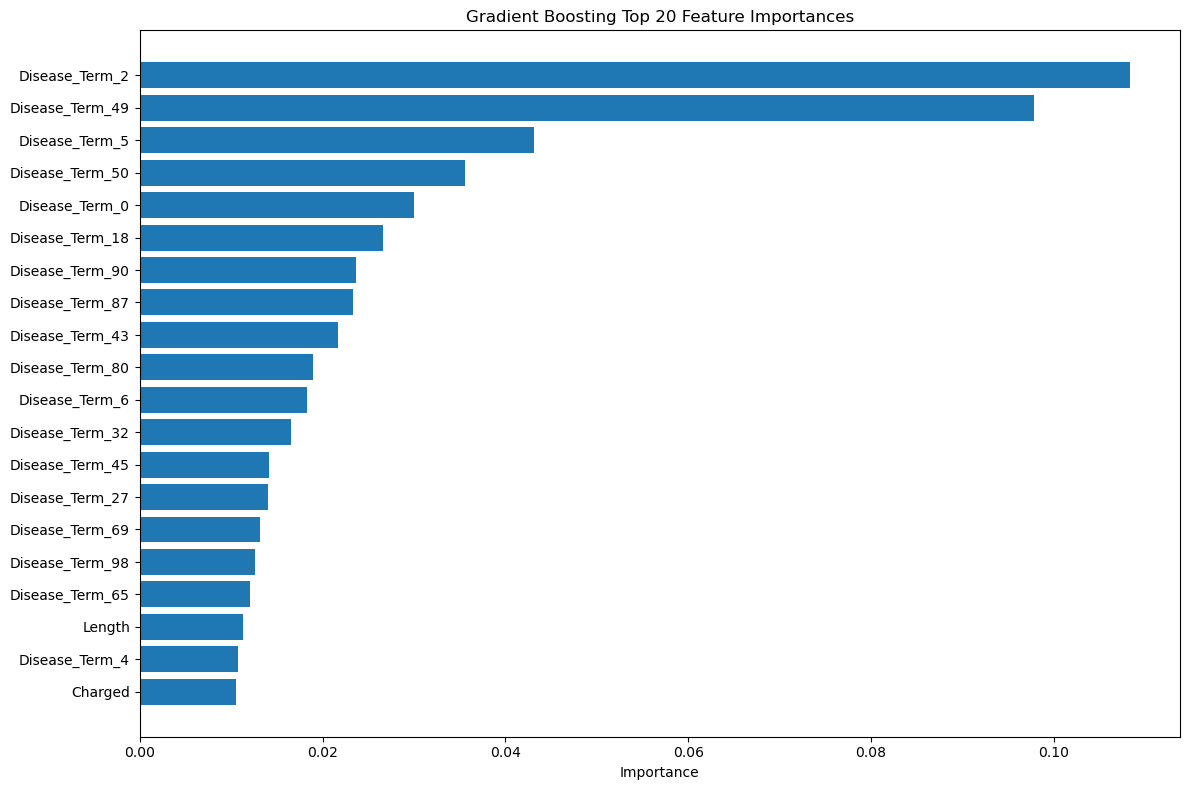


Most Important Features:
             Feature  RF_Importance  GB_Importance
73   Disease_Term_49       0.129113       0.097769
26    Disease_Term_2       0.085723       0.108367
60   Disease_Term_36       0.058264       0.004019
74   Disease_Term_50       0.045885       0.035616
29    Disease_Term_5       0.043536       0.043179
24    Disease_Term_0       0.037952       0.029953
42   Disease_Term_18       0.030484       0.026659
114  Disease_Term_90       0.029819       0.023711
30    Disease_Term_6       0.017990       0.018318
111  Disease_Term_87       0.017228       0.023340


In [7]:
#creates more interpretable feature names
sequence_feature_names = ['Length', 'Hydrophobic', 'Polar', 'Charged'] + [f'AA_{aa}' for aa in 'ACDEFGHIKLMNPQRSTVWY']
disease_feature_names = [f'Disease_Term_{i}' for i in range(disease_features.shape[1])]
feature_names = sequence_feature_names + disease_feature_names

#Random Forest Feature Importance.
rf_importances = rf_model.feature_importances_
rf_indices = np.argsort(rf_importances)[-20:]

plt.figure(figsize=(12, 8))
plt.title("Random Forest Top 20 Feature Importances")
plt.barh(range(20), rf_importances[rf_indices])
plt.yticks(range(20), [feature_names[i] for i in rf_indices])
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

#Gradient Boosting Feature Importance.
gb_importances = gb_model.feature_importances_
gb_indices = np.argsort(gb_importances)[-20:]

plt.figure(figsize=(12, 8))
plt.title("Gradient Boosting Top 20 Feature Importances")
plt.barh(range(20), gb_importances[gb_indices])
plt.yticks(range(20), [feature_names[i] for i in gb_indices])
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

#Feature Importance basic summary.
top_features = pd.DataFrame({
    'Feature': feature_names,
    'RF_Importance': rf_importances,
    'GB_Importance': gb_importances
})
print("\nMost Important Features:")
print(top_features.sort_values('RF_Importance', ascending=False).head(10))

Shows model performance as training data increases (Learning curve visualization):

- Blue line: Training score
- Orange line: Cross-validation score
- Shaded areas: Standard deviation of scores (confidence intervals)

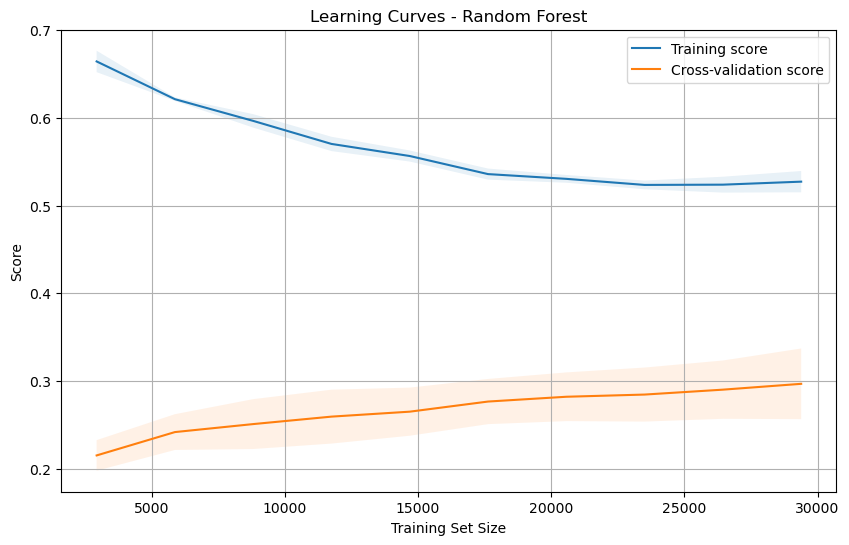

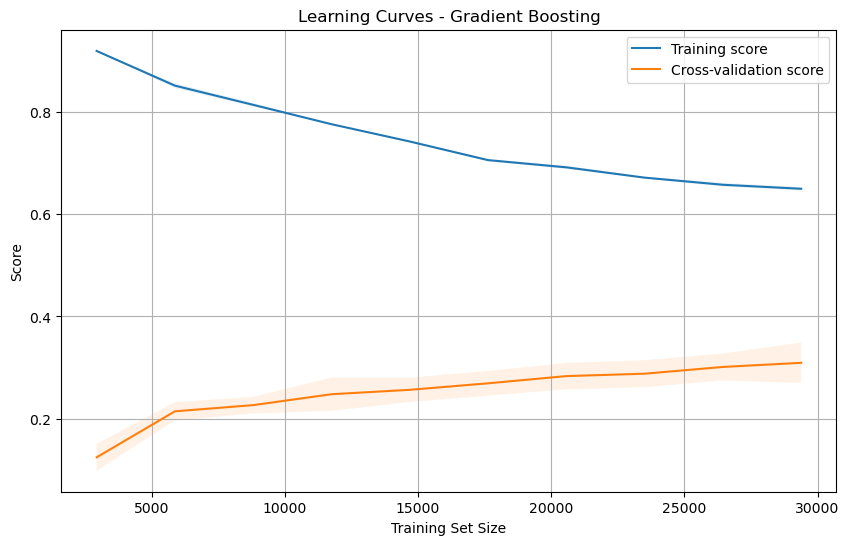

In [8]:
from sklearn.model_selection import learning_curve

def plot_learning_curves(model, X, y, title):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=5, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 10))
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, label='Training score')
    plt.plot(train_sizes, test_mean, label='Cross-validation score')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1)
    plt.title(f'Learning Curves - {title}')
    plt.xlabel('Training Set Size')
    plt.ylabel('Score')
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

#this plots the learning curves for each model.
plot_learning_curves(rf_model, X_train_scaled, y_train, 'Random Forest')
plot_learning_curves(gb_model, X_train_scaled, y_train, 'Gradient Boosting')

This visualziation compares actual vs predicted value distributions using KDE plots (prediction distribution):

- Identifies bias in predictions
- Shows if model captures full range of values
- Reveals systematic prediction errors

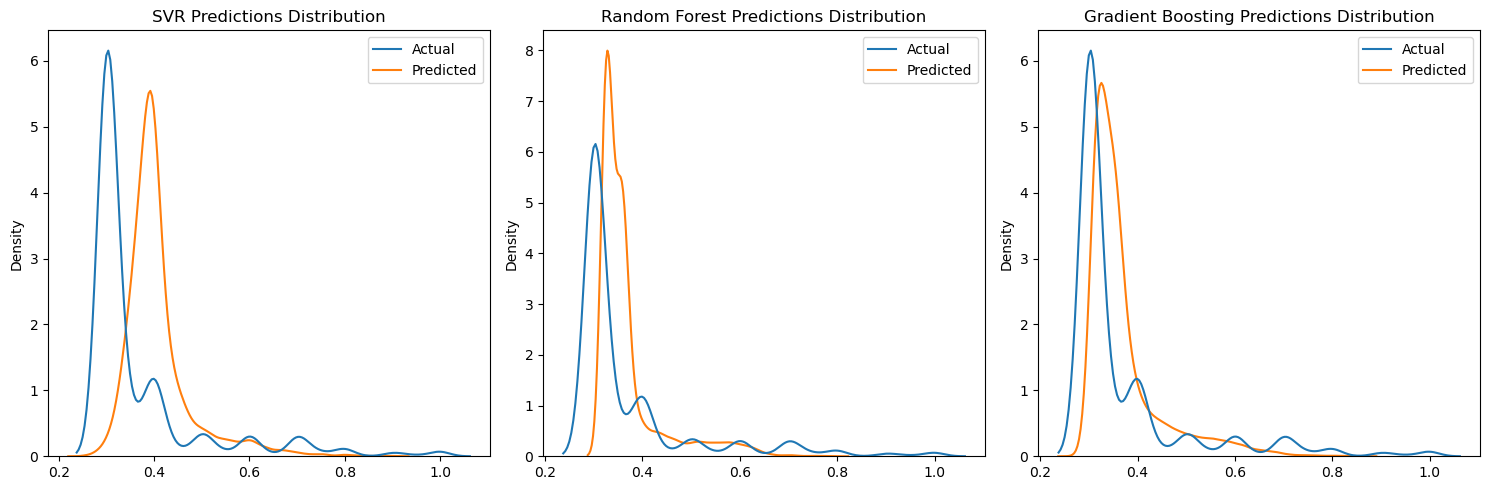

In [9]:
#this is for prediction distribution plot.
plt.figure(figsize=(15, 5))

plt.subplot(131)
sns.kdeplot(data=pd.DataFrame({'Actual': y_test, 'Predicted': svr_pred}))
plt.title('SVR Predictions Distribution')

plt.subplot(132)
sns.kdeplot(data=pd.DataFrame({'Actual': y_test, 'Predicted': rf_pred}))
plt.title('Random Forest Predictions Distribution')

plt.subplot(133)
sns.kdeplot(data=pd.DataFrame({'Actual': y_test, 'Predicted': gb_pred}))
plt.title('Gradient Boosting Predictions Distribution')

plt.tight_layout()
plt.show()

Shows histogram of prediction errors with KDE overlay:
- Compare error patterns across models
- Identify which models are more consistent
- Detect systematic biases

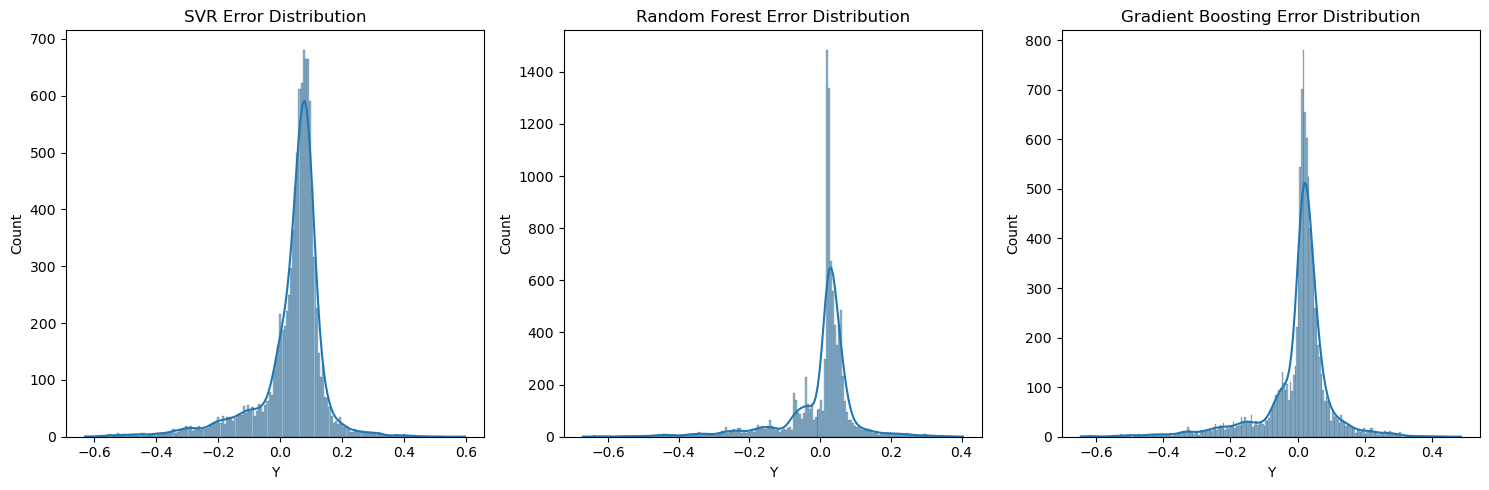

In [10]:
#this is for the error distribution plot.
plt.figure(figsize=(15, 5))

plt.subplot(131)
sns.histplot(svr_pred - y_test, kde=True)
plt.title('SVR Error Distribution')

plt.subplot(132)
sns.histplot(rf_pred - y_test, kde=True)
plt.title('Random Forest Error Distribution')

plt.subplot(133)
sns.histplot(gb_pred - y_test, kde=True)
plt.title('Gradient Boosting Error Distribution')

plt.tight_layout()
plt.show()

Color-coded matrix showing feature relationships:
- Identify redundant features
- Guide feature selection
- Detect multicollinearity
- Inform feature engineering decisions

Also for reference:
- Red → Positive correlations
- Blue → Negative correlations
- Color intensity → Correlation strength

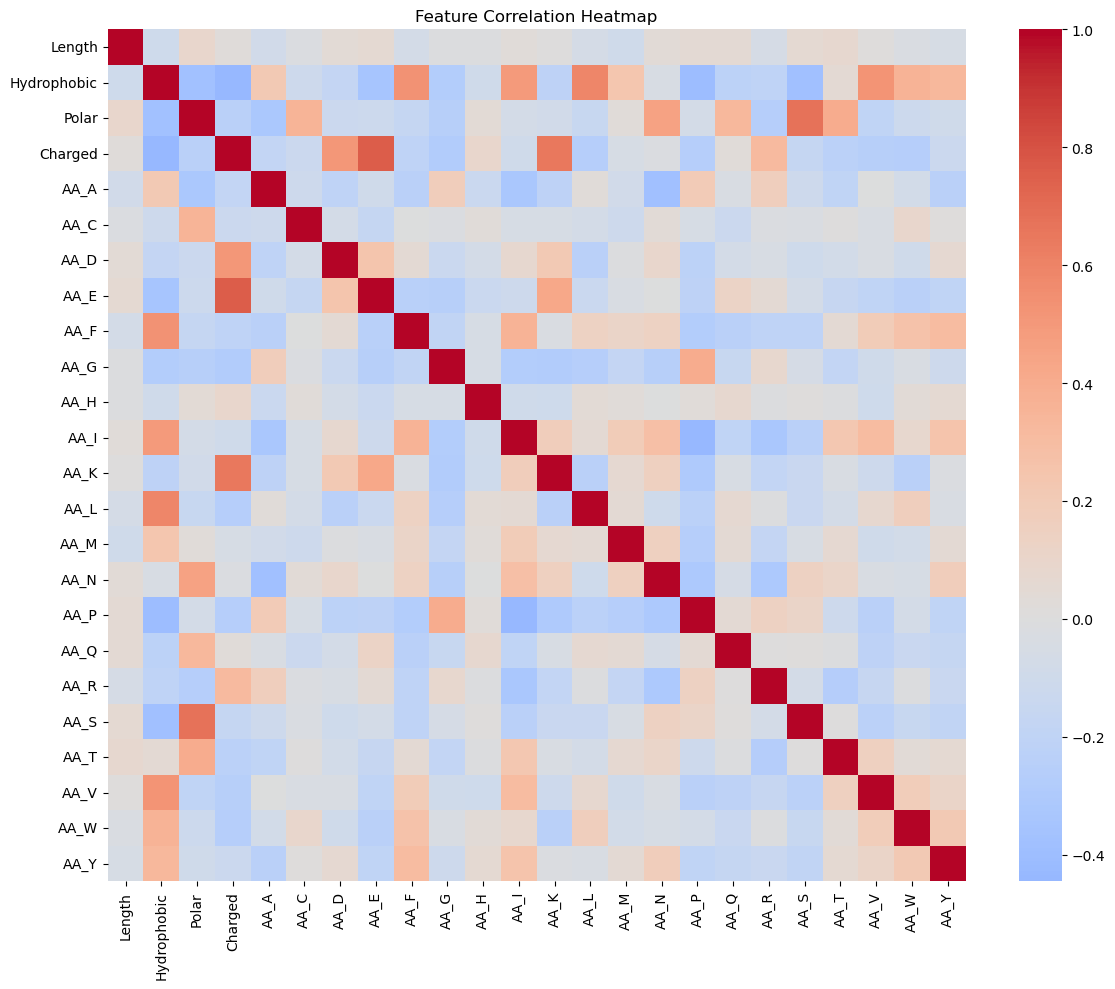

In [11]:
# this is for feature correlation heatmap.
sequence_features_df = pd.DataFrame(sequence_features, columns=sequence_feature_names)
plt.figure(figsize=(12, 10))
sns.heatmap(sequence_features_df.corr(), annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

Shows individual predictions vs actual values:
- Points: Individual predictions
- Regression line: Overall trend
- Shaded area: 95% confidence interval

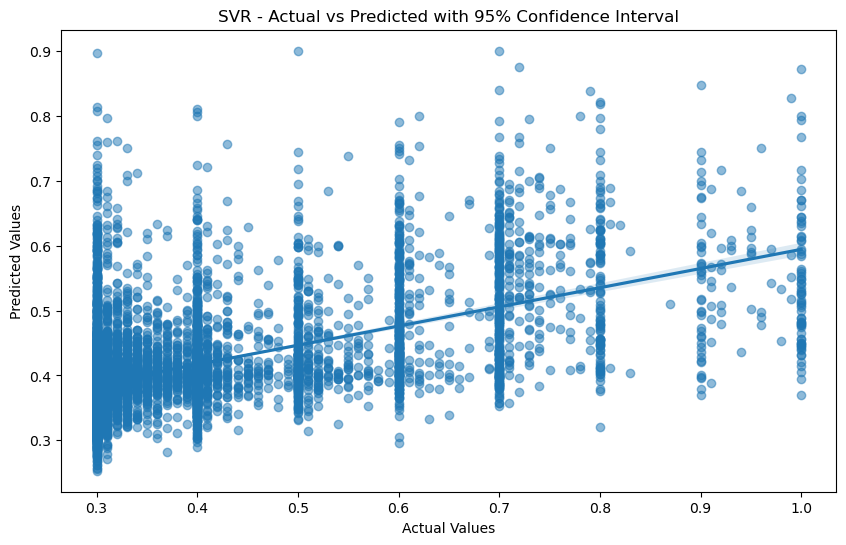

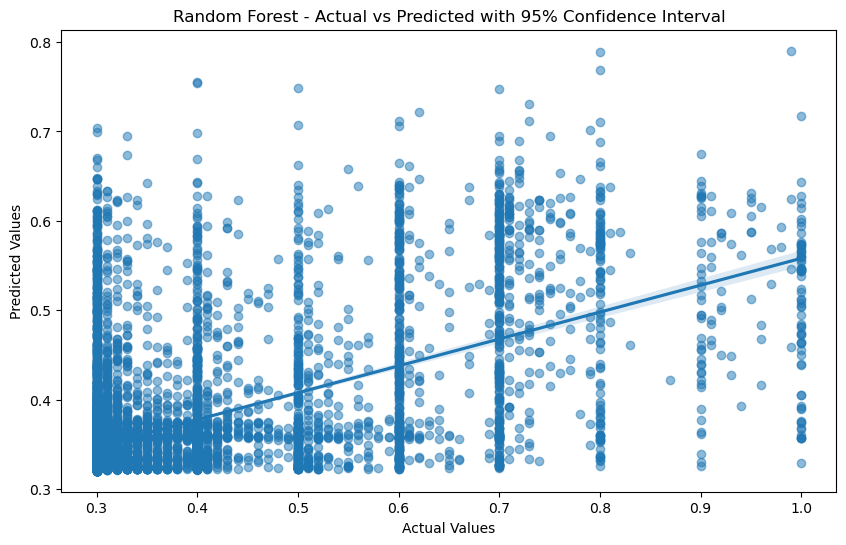

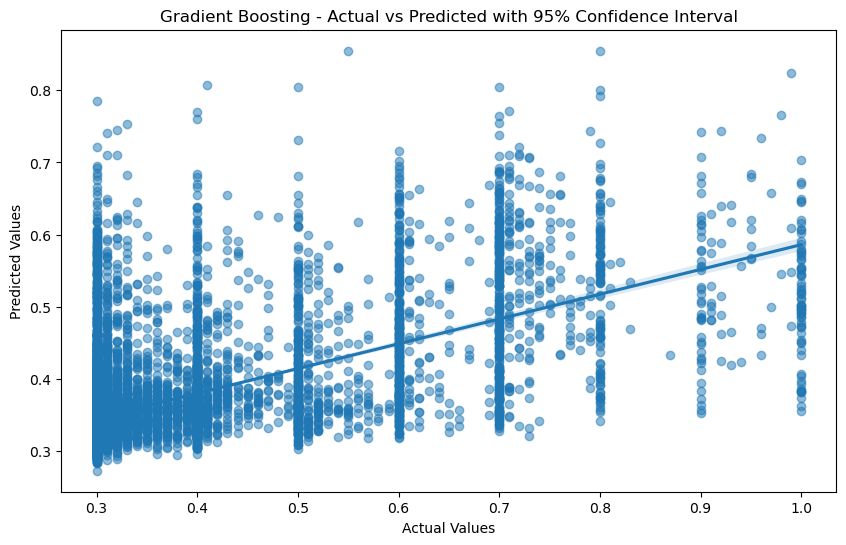

In [12]:
#and this finally shows actual vs predicted using scatterplot with confidence intervals.
for name, pred in [('SVR', svr_pred), ('Random Forest', rf_pred), ('Gradient Boosting', gb_pred)]:
    plt.figure(figsize=(10, 6))
    sns.regplot(x=y_test, y=pred, scatter_kws={'alpha':0.5})
    plt.title(f'{name} - Actual vs Predicted with 95% Confidence Interval')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.show()